In [1]:
import json
from datetime import datetime
import duckdb
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
# Filters
test_entity_group = 'CPR'
test_entity = 'CPR11'
test_sensor = 'vibration_rms'

In [3]:
# SQL module
# Pull sensor data for test_entity, test_sensor
# Join SPC limits

con = duckdb.connect(PROJECT_ROOT / "data" / "mfg.duckdb")
sql = """
SELECT
    entity,
    data.entity_group,
    CAST(timestamp AS TIMESTAMP) AS ts,
    operating_mode,
    hours_since_maintenance,
    failure_type,
    data.sensor,
    value,
    spc.ucl,
    spc.centerline,
    spc.lcl
FROM sensor_data AS data
LEFT JOIN sensor_spc_limits AS spc
ON data.entity_group = spc.entity_group
    AND data.sensor = spc.sensor
WHERE data.entity_group = ?
    AND entity = ? 
    AND data.sensor = ?
    AND operating_mode = 'normal'
ORDER BY ts;
"""

df_long = con.execute(sql, [test_entity_group, test_entity, test_sensor]).df()
con.close()

df_long.head()

,entity,entity_group,ts,operating_mode,hours_since_maintenance,failure_type,sensor,value,ucl,centerline,lcl
0,CPR11,CPR,2024-01-01 01:22:00,normal,393.91,none,vibration_rms,2.26,4.874969,2.651293,0.427617
1,CPR11,CPR,2024-01-01 04:46:00,normal,397.31,none,vibration_rms,2.14,4.874969,2.651293,0.427617
2,CPR11,CPR,2024-01-01 05:55:00,normal,398.46,none,vibration_rms,2.52,4.874969,2.651293,0.427617
3,CPR11,CPR,2024-01-01 06:07:00,normal,398.66,none,vibration_rms,2.10,4.874969,2.651293,0.427617
4,CPR11,CPR,2024-01-01 06:19:00,normal,398.86,none,vibration_rms,2.25,4.874969,2.651293,0.427617


In [4]:
# Preprocess module

#Generate EWMA column
EWMA_ALPHA = 0.2

# Deterministic ordering
df_long = df_long.sort_values(['entity', 'sensor', 'ts']).copy()

# Define maintenance blocks per chart (reset when hours_since_maintenance == 0)
df_long['maintenance_block'] = (
    df_long.groupby(['entity', 'sensor'])['hours_since_maintenance']
          .transform(lambda s: (s == 0).cumsum())
)

# EWMA per (entity_group, sensor, maintenance_block)
# transform guarantees alignment and preserves all columns
df_long['ewma'] = (
    df_long.groupby(['entity', 'sensor', 'maintenance_block'])['value']
          .transform(lambda s: s.ewm(alpha=EWMA_ALPHA, adjust=False).mean())
)

# Generate SPC violation column

df_long['spc_violation'] = (
    (df_long['ewma'] > df_long['ucl']) |
    (df_long['ewma'] < df_long['lcl'])
)

df_long = df_long.drop(columns=['maintenance_block'])


In [5]:
df_long.head()

,entity,entity_group,ts,operating_mode,hours_since_maintenance,failure_type,sensor,value,ucl,centerline,lcl,ewma,spc_violation
0,CPR11,CPR,2024-01-01 01:22:00,normal,393.91,none,vibration_rms,2.26,4.874969,2.651293,0.427617,2.260000,False
1,CPR11,CPR,2024-01-01 04:46:00,normal,397.31,none,vibration_rms,2.14,4.874969,2.651293,0.427617,2.236000,False
2,CPR11,CPR,2024-01-01 05:55:00,normal,398.46,none,vibration_rms,2.52,4.874969,2.651293,0.427617,2.292800,False
3,CPR11,CPR,2024-01-01 06:07:00,normal,398.66,none,vibration_rms,2.10,4.874969,2.651293,0.427617,2.254240,False
4,CPR11,CPR,2024-01-01 06:19:00,normal,398.86,none,vibration_rms,2.25,4.874969,2.651293,0.427617,2.253392,False


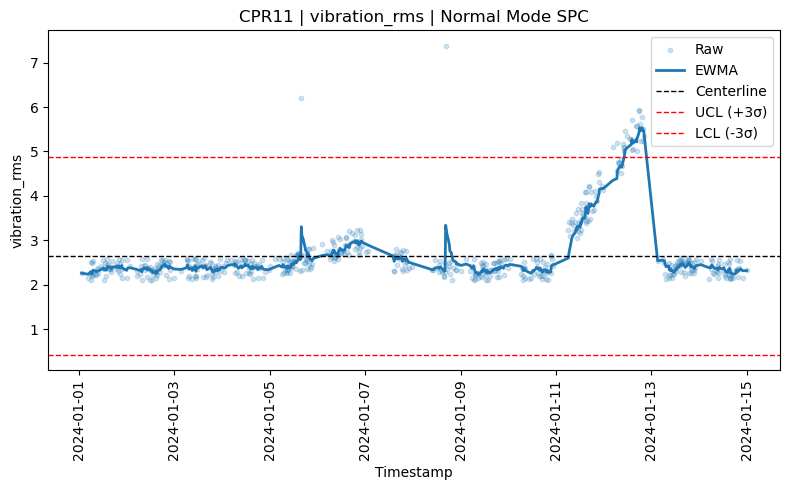

In [6]:
# Plotting Module

# Re-apply test filters
chart_df = df_long[
    (df_long["entity_group"] == test_entity_group) &
    (df_long["entity"] == test_entity) &
    (df_long["sensor"] == test_sensor)
].copy()

chart_df = chart_df.sort_values("ts")

# Get SPC limits

centerline = chart_df["centerline"].iloc[0]
ucl = chart_df["ucl"].iloc[0]
lcl = chart_df["lcl"].iloc[0]

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(
            chart_df["ts"],
            chart_df["value"],
            alpha=0.2,
            s=10,
            label="Raw"
        )
plt.plot(
        chart_df["ts"],
        chart_df["ewma"],
        linewidth=2,
        label="EWMA"
    )

plt.axhline(centerline, linestyle="--", linewidth=1, color="black", label="Centerline")
plt.axhline(ucl, linestyle="--", linewidth=1, color="red", label="UCL (+3σ)")
plt.axhline(lcl, linestyle="--", linewidth=1, color="red", label="LCL (-3σ)")

plt.title(f"{test_entity} | {test_sensor} | Normal Mode SPC")
plt.xticks(rotation='vertical')
plt.xlabel("Timestamp")
plt.ylabel(test_sensor)
plt.legend(loc="best")
plt.tight_layout()
plt.show();